In [164]:
import xml.etree.ElementTree as ET
import numpy as np
import scipy as sp
from scipy.io import whosmat, loadmat
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from scipy.stats import wilcoxon
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import average_precision_score

In [76]:
from pathlib import Path

chemin = Path("/mnt/hubel-data-149/Rat012/Rat012_2025-12-15")


In [77]:
for f in sorted(chemin.iterdir()):
    print(f.name)

BeforeCheckSameClu
In
InfraSlowRhythm
IniClu
Rat012_2025-12-15.cat.evt
Rat012_2025-12-15.cat.evt.old
Rat012_2025-12-15.clu.1
Rat012_2025-12-15.clu.10
Rat012_2025-12-15.clu.11
Rat012_2025-12-15.clu.12
Rat012_2025-12-15.clu.12.03.05.2026.14.46
Rat012_2025-12-15.clu.2
Rat012_2025-12-15.clu.3
Rat012_2025-12-15.clu.4
Rat012_2025-12-15.clu.5
Rat012_2025-12-15.clu.6
Rat012_2025-12-15.clu.7
Rat012_2025-12-15.clu.8
Rat012_2025-12-15.clu.9
Rat012_2025-12-15.dat
Rat012_2025-12-15.deltaWaves.events.mat
Rat012_2025-12-15.drowsiness
Rat012_2025-12-15.fet.1
Rat012_2025-12-15.fet.10
Rat012_2025-12-15.fet.11
Rat012_2025-12-15.fet.12
Rat012_2025-12-15.fet.2
Rat012_2025-12-15.fet.3
Rat012_2025-12-15.fet.4
Rat012_2025-12-15.fet.5
Rat012_2025-12-15.fet.6
Rat012_2025-12-15.fet.7
Rat012_2025-12-15.fet.8
Rat012_2025-12-15.fet.9
Rat012_2025-12-15.fil
Rat012_2025-12-15.klg.1
Rat012_2025-12-15.klg.10
Rat012_2025-12-15.klg.11
Rat012_2025-12-15.klg.12
Rat012_2025-12-15.klg.2
Rat012_2025-12-15.klg.3
Rat012_2025-12-

In [78]:
HPC_groups =[7, 8, 9]
MPFC_groups =[10, 11, 12]  

hpc_files =[]
mpfc_files =[]

for g in HPC_groups:
    hpc_files.append({
        "group": g,
        "clu" : next(chemin.glob(f"*.clu.{g}")),
        "res" : next(chemin.glob(f"*.res.{g}"))
    })

for g in MPFC_groups:
    mpfc_files.append({
        "group": g,
        "clu" : next(chemin.glob(f"*.clu.{g}")),
        "res" : next(chemin.glob(f"*.res.{g}"))
    })

print("HPC:")
for x in hpc_files:
    print("HPC groupe", x["group"])
    print("clu:", x["clu"])  
    print("res:", x["res"]) 

print("mPFC:")
for x in mpfc_files:
    print("mPFC groupe", x["group"])
    print("clu:", x["clu"])  
    print("res:", x["res"]) 

HPC:
HPC groupe 7
clu: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.clu.7
res: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.res.7
HPC groupe 8
clu: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.clu.8
res: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.res.8
HPC groupe 9
clu: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.clu.9
res: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.res.9
mPFC:
mPFC groupe 10
clu: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.clu.10
res: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.res.10
mPFC groupe 11
clu: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.clu.11
res: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.res.11
mPFC groupe 12
clu: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.clu.12
res: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.res.12


In [79]:
xml_file = next(chemin.glob("*.xml"))
tree = ET.parse(xml_file)
root = tree.getroot()

sampling_rate = None

for elem in root.iter():
    if elem.tag.lower().endswith("samplingrate"):
        sampling_rate = float(elem.text)
        break

print("fichier xml:", xml_file.name)
print("freq d'ech :", sampling_rate, "Hz")

fichier xml: Rat012_2025-12-15.xml
freq d'ech : 20000.0 Hz


In [80]:
def load_clu_res(clu_path, res_path):

    clu_raw = np.loadtxt(clu_path, dtype=np.int64)
    res = np.loadtxt(res_path, dtype=np.int64)

    clu = clu_raw[1:]

    if len(clu) != len(res):
        raise ValueError(
            f"Longueurs différentes : clu={len(clu)}, res={len(res)}"
        ) 

    return clu, res

In [81]:
FE = 20_000

def load_units(files, fs):
    units ={}

    for x in files:
        group = x["group"]

        clu, res = load_clu_res(x["clu"], x["res"])
        spike_times = res / FE

        for cluster in np.unique(clu):
            units[(group, cluster)]= spike_times[clu == cluster]

    return units

hpc_units = load_units(hpc_files, FE)
mpfc_units = load_units(mpfc_files, FE)     

In [82]:
delta_files =[
    f for f in chemin.iterdir()
    if "delta" in f.name.lower()
] 

for f in delta_files:
    print(f.name)

Rat012_2025-12-15.deltaWaves.events.mat


In [83]:
delta_file= delta_files[0] 

print("Fichier :", delta_file)
print("Taille :", delta_file.stat().st_size / 1024, "KB")

Fichier : /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.deltaWaves.events.mat
Taille : 103.7431640625 KB


In [84]:
with open(delta_file, "rb") as f:
    header = f.read(100)

print(header)

b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Tue Mar 31 15:44:19 2026                        '


In [85]:
for x in whosmat(delta_file):
    print(x)

('deltaWaves', (1, 1), 'struct')


In [86]:
mat = loadmat(delta_file, simplify_cells=True)

print(mat.keys())

deltawaves = mat["deltaWaves"]

print(type(deltawaves)) 
print(deltawaves.keys())

dict_keys(['__header__', '__version__', '__globals__', 'deltaWaves'])
<class 'dict'>
dict_keys(['timestamps', 'peaks', 'peakNormedPower', 'detectorName', 'troughValue', 'badIntervals'])


In [87]:
for key in ["timestamps", "peaks"]:
    x = np.asarray(deltawaves[key])

    print("\n", key)
    print("shape:", x.shape)
    print("dtype:", x.dtype)
    print("premières valeurs:")
    print(x[:10]) 


 timestamps
shape: (3338, 2)
dtype: float64
premières valeurs:
[[507.7656 508.0152]
 [789.5    789.86  ]
 [802.044  802.316 ]
 [842.6312 842.9016]
 [846.8552 847.1416]
 [861.3624 861.7264]
 [872.0072 872.3392]
 [874.3592 874.6456]
 [876.1632 876.3248]
 [878.7104 879.0536]]

 peaks
shape: (3338,)
dtype: float64
premières valeurs:
[507.8808 789.7328 802.1736 842.7584 846.9912 861.5904 872.1384 874.5032
 876.164  878.8808]


In [88]:
delta_peaks = np.asarray(deltawaves["peaks"], dtype=float)
print("nombre de delta waves:", len(delta_peaks))
print(delta_peaks[:10])

nombre de delta waves: 3338
[507.8808 789.7328 802.1736 842.7584 846.9912 861.5904 872.1384 874.5032
 876.164  878.8808]


In [89]:
def build_hpc_matrix(hpc_units, delta_peaks, window=0.200):
    unit_ids = list(hpc_units.keys())
    X = np.zeros((len(delta_peaks), len(unit_ids)), dtype=int)

    for j, unit_id in enumerate(unit_ids):
        spikes = np.asarray(hpc_units[unit_id])

        left = np.searchsorted(spikes, delta_peaks - window, side = "left")
        right = np.searchsorted(spikes, delta_peaks, side = "right")

        X[:, j] = right - left

    return X, unit_ids 

In [90]:
X_hpc, hpc_unit_ids = build_hpc_matrix (hpc_units, delta_peaks)

print("Shape X_hpc:", X_hpc.shape)
print("Unités HPC:", hpc_unit_ids)

Shape X_hpc: (3338, 67)
Unités HPC: [(7, np.int64(0)), (7, np.int64(1)), (7, np.int64(3)), (7, np.int64(7)), (7, np.int64(9)), (7, np.int64(10)), (7, np.int64(13)), (7, np.int64(17)), (7, np.int64(20)), (7, np.int64(25)), (7, np.int64(31)), (7, np.int64(33)), (7, np.int64(35)), (7, np.int64(38)), (7, np.int64(41)), (7, np.int64(42)), (7, np.int64(44)), (7, np.int64(50)), (7, np.int64(51)), (7, np.int64(52)), (7, np.int64(55)), (7, np.int64(58)), (7, np.int64(67)), (7, np.int64(68)), (7, np.int64(71)), (7, np.int64(73)), (7, np.int64(76)), (7, np.int64(80)), (7, np.int64(84)), (7, np.int64(89)), (7, np.int64(96)), (7, np.int64(101)), (7, np.int64(103)), (7, np.int64(104)), (7, np.int64(105)), (7, np.int64(106)), (8, np.int64(0)), (8, np.int64(1)), (8, np.int64(5)), (8, np.int64(6)), (8, np.int64(13)), (8, np.int64(23)), (8, np.int64(26)), (8, np.int64(28)), (8, np.int64(29)), (8, np.int64(32)), (8, np.int64(33)), (8, np.int64(45)), (8, np.int64(46)), (9, np.int64(0)), (9, np.int64(1)), 

In [91]:
hpc_units = {
    k: value 
    for k, value in hpc_units.items()
    if k[1] > 1 
} 

mpfc_units = {
    k: value 
    for k, value in mpfc_units.items()
    if k[1] > 1 
} 

In [92]:
print("HPC:", len(hpc_units), "unités")
print("mPFC:", len(mpfc_units), "unités")

print(list(hpc_units.keys()))
print(list(mpfc_units.keys()))

HPC: 61 unités
mPFC: 22 unités
[(7, np.int64(3)), (7, np.int64(7)), (7, np.int64(9)), (7, np.int64(10)), (7, np.int64(13)), (7, np.int64(17)), (7, np.int64(20)), (7, np.int64(25)), (7, np.int64(31)), (7, np.int64(33)), (7, np.int64(35)), (7, np.int64(38)), (7, np.int64(41)), (7, np.int64(42)), (7, np.int64(44)), (7, np.int64(50)), (7, np.int64(51)), (7, np.int64(52)), (7, np.int64(55)), (7, np.int64(58)), (7, np.int64(67)), (7, np.int64(68)), (7, np.int64(71)), (7, np.int64(73)), (7, np.int64(76)), (7, np.int64(80)), (7, np.int64(84)), (7, np.int64(89)), (7, np.int64(96)), (7, np.int64(101)), (7, np.int64(103)), (7, np.int64(104)), (7, np.int64(105)), (7, np.int64(106)), (8, np.int64(5)), (8, np.int64(6)), (8, np.int64(13)), (8, np.int64(23)), (8, np.int64(26)), (8, np.int64(28)), (8, np.int64(29)), (8, np.int64(32)), (8, np.int64(33)), (8, np.int64(45)), (8, np.int64(46)), (9, np.int64(3)), (9, np.int64(7)), (9, np.int64(8)), (9, np.int64(10)), (9, np.int64(11)), (9, np.int64(15)), (9

In [93]:
X_hpc, hpc_unit_ids = build_hpc_matrix (hpc_units, delta_peaks)

print("Dimensions X_hpc:", X_hpc.shape)

Dimensions X_hpc: (3338, 61)


In [94]:
def build_mpfc_targets(mpfc_units, delta_peaks, half_window=0.015):
    unit_ids = list(mpfc_units.keys())

    Y = np.zeros((len(delta_peaks), len(unit_ids)), dtype=int)

    for j, unit_id in enumerate(unit_ids):
        spikes = np.asarray(mpfc_units[unit_id])

        left = np.searchsorted(spikes, delta_peaks - half_window, side = "left")
        right = np.searchsorted(spikes, delta_peaks + half_window, side = "right")

        Y[:, j] = (right > left).astype(int)

    return Y, unit_ids 

In [95]:
Y_mpfc, mpfc_units_ids = build_mpfc_targets (mpfc_units, delta_peaks)

print("X_hpc:", X_hpc.shape)
print("Y_mpfc:", Y_mpfc.shape)

X_hpc: (3338, 61)
Y_mpfc: (3338, 22)


In [96]:
print("Valeurs dans X:", np.unique(X_hpc))
print("Valeurs dans Y:", np.unique(Y_mpfc))

print("NaN dans X:", np.isnan(X_hpc).any())
print("NaN dans Y:", np.isnan(Y_mpfc).any())

Valeurs dans X: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]
Valeurs dans Y: [0 1]
NaN dans X: False
NaN dans Y: False


In [97]:
n_delta_spikes = Y_mpfc.sum(axis=0)

for unit_id, n in zip(mpfc_units_ids, n_delta_spikes):
    print(f"Unité {unit_id}: {n} delta spikes")

Unité (10, np.int64(2)): 6 delta spikes
Unité (10, np.int64(5)): 24 delta spikes
Unité (10, np.int64(24)): 129 delta spikes
Unité (10, np.int64(25)): 29 delta spikes
Unité (11, np.int64(2)): 270 delta spikes
Unité (11, np.int64(4)): 1 delta spikes
Unité (11, np.int64(11)): 16 delta spikes
Unité (11, np.int64(29)): 2 delta spikes
Unité (11, np.int64(33)): 75 delta spikes
Unité (11, np.int64(37)): 14 delta spikes
Unité (11, np.int64(40)): 3 delta spikes
Unité (11, np.int64(41)): 1 delta spikes
Unité (11, np.int64(43)): 18 delta spikes
Unité (11, np.int64(44)): 7 delta spikes
Unité (12, np.int64(8)): 14 delta spikes
Unité (12, np.int64(14)): 1 delta spikes
Unité (12, np.int64(23)): 0 delta spikes
Unité (12, np.int64(26)): 3 delta spikes
Unité (12, np.int64(33)): 2 delta spikes
Unité (12, np.int64(37)): 98 delta spikes
Unité (12, np.int64(38)): 103 delta spikes
Unité (12, np.int64(39)): 14 delta spikes


In [98]:
print("Nombre total de spikes HPC dans les fenêtres:", X_hpc.sum())

spikes_par_hpc_unit = X_hpc.sum(axis=0)

for unit_id, n in zip(hpc_unit_ids, spikes_par_hpc_unit):
    print(f"Unité {unit_id}: {n} spikes dans les fenêtres")

Nombre total de spikes HPC dans les fenêtres: 54520
Unité (7, np.int64(3)): 512 spikes dans les fenêtres
Unité (7, np.int64(7)): 157 spikes dans les fenêtres
Unité (7, np.int64(9)): 2200 spikes dans les fenêtres
Unité (7, np.int64(10)): 125 spikes dans les fenêtres
Unité (7, np.int64(13)): 250 spikes dans les fenêtres
Unité (7, np.int64(17)): 432 spikes dans les fenêtres
Unité (7, np.int64(20)): 365 spikes dans les fenêtres
Unité (7, np.int64(25)): 263 spikes dans les fenêtres
Unité (7, np.int64(31)): 417 spikes dans les fenêtres
Unité (7, np.int64(33)): 3126 spikes dans les fenêtres
Unité (7, np.int64(35)): 172 spikes dans les fenêtres
Unité (7, np.int64(38)): 291 spikes dans les fenêtres
Unité (7, np.int64(41)): 404 spikes dans les fenêtres
Unité (7, np.int64(42)): 714 spikes dans les fenêtres
Unité (7, np.int64(44)): 101 spikes dans les fenêtres
Unité (7, np.int64(50)): 216 spikes dans les fenêtres
Unité (7, np.int64(51)): 1311 spikes dans les fenêtres
Unité (7, np.int64(52)): 436 s

In [99]:
keep_mpfc = Y_mpfc.sum(axis=0) >= 2

Y_mpfc = Y_mpfc[:, keep_mpfc]
mpfc_units_ids = [unit_id for unit_id, keep in zip(mpfc_units_ids, keep_mpfc) if keep] 

keep_hpc = X_hpc.sum(axis=0) > 0

X_hpc = X_hpc[:, keep_hpc]
hpc_unit_ids = [unit_id for unit_id, keep in zip(hpc_unit_ids, keep_hpc) if keep]

print("X_hpc:", X_hpc.shape)
print("Y_mpfc:", Y_mpfc.shape)

X_hpc: (3338, 61)
Y_mpfc: (3338, 18)


In [100]:
n_delta_spikes = Y_mpfc.sum(axis=0)

for unit_id, n in zip(mpfc_units_ids, n_delta_spikes):
    print(unit_id, ":", n)

(10, np.int64(2)) : 6
(10, np.int64(5)) : 24
(10, np.int64(24)) : 129
(10, np.int64(25)) : 29
(11, np.int64(2)) : 270
(11, np.int64(11)) : 16
(11, np.int64(29)) : 2
(11, np.int64(33)) : 75
(11, np.int64(37)) : 14
(11, np.int64(40)) : 3
(11, np.int64(43)) : 18
(11, np.int64(44)) : 7
(12, np.int64(8)) : 14
(12, np.int64(26)) : 3
(12, np.int64(33)) : 2
(12, np.int64(37)) : 98
(12, np.int64(38)) : 103
(12, np.int64(39)) : 14


In [101]:
def make_folds(y, random_state=42):

    rgn = np.random.default_rng(random_state)
    positive_indices = np.where(y==1)[0]
    negative_indices = np.where(y==0)[0]

    n_positive = len(positive_indices)

    if n_positive < 2:
        raise ValueError("Pas assez d'exemples positifs pour faire des folds.")

    rgn.shuffle(positive_indices)
    rgn.shuffle(negative_indices)

    negatives_parts = np.array_split(negative_indices, n_positive)

    folds = []

    for i in range(n_positive):
        test_indices = np.concatenate(([positive_indices[i]], negatives_parts[i]))
        train_indices = np.setdiff1d(np.arange(len(y)), test_indices)
        folds.append((train_indices, test_indices))

    return folds

In [102]:
neuron_id = 0

y = Y_mpfc[:, neuron_id]

print("Neurone:", mpfc_units_ids[neuron_id])
print("Nombre de delta spikes:", y.sum())

folds = make_folds(y)

print("Nombre de folds:", len(folds))

Neurone: (10, np.int64(2))
Nombre de delta spikes: 6
Nombre de folds: 6


In [103]:
for i, (train_indices, test_indices) in enumerate(folds):
    print(f"Fold {i+1}:")
    print("  Train indices:", train_indices)
    print("  Test indices:", test_indices)
    print("  Nombre d'exemples positifs dans le test:", np.sum(y[test_indices]))

Fold 1:
  Train indices: [   0    2    3 ... 3334 3336 3337]
  Test indices: [1910   70  921  125  476 1698 3226  749  855 1719 3325  558    8 3079
 1750  415  352 1522 3335 3093  993  582  623 1906 2178 1704  553 2326
 1174 2461 2167 1013 1942  404 2102 2009 1074 2431 3015 2006  703 2742
 2392   28   17  787  129 1442 2043 1215 3007 2724  514  452 2913  242
 1209 2254  495 1360 3016 1708  175 1713 2480  214 2278 1239 2002 3190
  678 2984 3170 1630  592  850 1309 1438   78 2061  285 2187 1847  454
 1376 3013 1260 2056 2882 1022 2607  773 2531   50 1990 1198 1586 2271
  303 2309  740 1019 1935 3195 1710 1279 2132  192 1068 1695  693  579
 2764 2957 2586 1934 3207  620 1143 2027 2075 2321  223 2639 2506 1753
 3221 1601 2525 2185 1134  178 2844   80 1246 2384 1101 1773 2045 3211
 1097 2477 2474 1950 1315 1569   68 2397 2063 1545 2544 2290 1777 1206
  957 1473 2892  687 2499 1488 2078 1623  365 2035 1034  435 2942 1154
  510  158 1486  400  992  100 2708  466 1441 2950 2864 2920 3147  530


In [104]:
predictions = np.zeros(len(y), dtype=int)

train_indices, test_indices = folds[0]

X_train = X_hpc[train_indices]
X_test = X_hpc[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("Nombre d'exemples positifs dans le train:", np.sum(y_train))
print("Nombre d'exemples positifs dans le test:", np.sum(y_test))

X_train shape: (2781, 61)
X_test shape: (557, 61)
y_train shape: (2781,)
y_test shape: (557,)
Nombre d'exemples positifs dans le train: 5
Nombre d'exemples positifs dans le test: 1


In [105]:
X_train_glm = sm.add_constant(X_train, has_constant='add')
X_test_glm = sm.add_constant(X_test, has_constant='add')

print("X_train avant:", X_train.shape)
print("X_train après:", X_train_glm.shape)
print("X_test avant:", X_test.shape)
print("X_test après:", X_test_glm.shape)

X_train avant: (2781, 61)
X_train après: (2781, 62)
X_test avant: (557, 61)
X_test après: (557, 62)


In [106]:
model = sm.GLM(y_train, X_train_glm, family=sm.families.Binomial())
results = model.fit()

print(results.converged)

/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/families/links.py:203: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(


True


/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(


In [107]:
pred_test = results.predict(X_test_glm)

print("Nombre de prédictions:", len(pred_test))
print("Minimum:", np.min(pred_test))
print("Maximum:", np.max(pred_test))
print("Nan:", np.isnan(pred_test).any())
print("Inf:", np.isinf(pred_test).any())

print(pred_test[:20])


Nombre de prédictions: 557
Minimum: 0.0
Maximum: 1.0
Nan: False
Inf: False
[2.22536236e-108 3.33201308e-173 9.87869418e-129 6.60922144e-201
 1.08081863e-118 6.96512150e-219 5.47890596e-108 1.43385904e-143
 1.65421321e-044 0.00000000e+000 0.00000000e+000 0.00000000e+000
 3.10871105e-146 2.73284587e-173 1.23807789e-298 1.98673322e-080
 1.16236938e-115 0.00000000e+000 0.00000000e+000 0.00000000e+000]


In [108]:
neuron_id = np.argmax(n_delta_spikes)

y = Y_mpfc[:, neuron_id]

print("Neurone:", mpfc_units_ids[neuron_id])
print("Nombre de delta spikes:", y.sum())

Neurone: (11, np.int64(2))
Nombre de delta spikes: 270


In [109]:
folds = make_folds(y)
print("Nombre de folds:", len(folds))

Nombre de folds: 270


In [110]:
train_indices, test_indices = folds[0]

X_train = X_hpc[train_indices]
X_test = X_hpc[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]

X_train_glm = sm.add_constant(X_train, has_constant='add')
X_test_glm = sm.add_constant(X_test, has_constant='add')

model = sm.GLM(y_train, X_train_glm, family=sm.families.Binomial())
results = model.fit()

pred_test = results.predict(X_test_glm)

print("Convergence:", results.converged)
print("Minimum:", np.min(pred_test))
print("Maximum:", np.max(pred_test))
print("Nan:", np.isnan(pred_test).any())
print("Inf:", np.isinf(pred_test).any())
print("Nombre d'exemples positifs dans le train:", np.sum(y_train))
print("Nombre d'exemples positifs dans le test:", np.sum(y_test))

Convergence: True
Minimum: 0.002611922052412819
Maximum: 0.21492947765552875
Nan: False
Inf: False
Nombre d'exemples positifs dans le train: 269
Nombre d'exemples positifs dans le test: 1


In [111]:
predictions = np.zeros(len(y), dtype=float)

for train_indices, test_indices in folds:
    X_train = X_hpc[train_indices]
    X_test = X_hpc[test_indices]

    y_train = y[train_indices]
    y_test = y[test_indices]

    X_train_glm = sm.add_constant(X_train, has_constant='add')
    X_test_glm = sm.add_constant(X_test, has_constant='add')

    model = sm.GLM(y_train, X_train_glm, family=sm.families.Binomial())
    results = model.fit()

    pred_test = results.predict(X_test_glm)

    predictions[test_indices] = results.predict(X_test_glm)

print("Nombre de prédictions:", len(predictions))
print("Minimum:", np.min(predictions))
print("Maximum:", np.max(predictions))
print("Nan:", np.isnan(predictions).any())
print("Inf:", np.isinf(predictions).any())

print("Nombre de valeurs prédites > 0 :", (predictions > 0).sum())

Nombre de prédictions: 3338
Minimum: 0.00015460682586303568
Maximum: 0.5794746873796265
Nan: False
Inf: False
Nombre de valeurs prédites > 0 : 3338


In [112]:
pred_pos = predictions[y == 1]
pred_neg = predictions[y == 0]

print("Nombre de prédictions positives:", len(pred_pos))
print("Nombre de prédictions négatives:", len(pred_neg))

print("Mediane des prédictions si delta spike:", np.median(pred_pos))
print("Mediane des prédictions si pas de delta spike:", np.median(pred_neg))

print("Moyenne des prédictions si delta spike:", np.mean(pred_pos))
print("Moyenne des prédictions si pas de delta spike:", np.mean(pred_neg))

Nombre de prédictions positives: 270
Nombre de prédictions négatives: 3068
Mediane des prédictions si delta spike: 0.08840082236526248
Mediane des prédictions si pas de delta spike: 0.06847045345778868
Moyenne des prédictions si delta spike: 0.10843143392702811
Moyenne des prédictions si pas de delta spike: 0.07878738184828117


In [113]:
errors = np.abs(predictions - y)
e = np.median(errors)

print("Erreur réelle e :", e)
print("Erreur moyenne :", np.mean(errors))

Erreur réelle e : 0.0726551319778615
Erreur moyenne : 0.1445306172409314


In [114]:
rgn = np.random.default_rng(42)

n_shuffles = 1000
shuffled_errors = np.zeros(n_shuffles, dtype=float)

for i in range(n_shuffles):

    shuffled_predictions = rgn.permutation(predictions)
    errors_shuffled = np.abs(shuffled_predictions - y)
    shuffled_errors[i] = np.median(errors_shuffled)

e_shuffled = np.median(shuffled_errors)

g = e_shuffled/e

print("Erreur réelle e :", e)
print("Erreur shufflée e_shuffled :", e_shuffled)
print("Prédiction gain g :", g)

Erreur réelle e : 0.0726551319778615
Erreur shufflée e_shuffled : 0.07359790225356545
Prédiction gain g : 1.0129759626063473


In [115]:
def compute_pred_gain(X, y, n_shuffles=1000, random_state=42, folds=None):

    if folds is None:
        folds = make_folds(y, random_state=random_state)
    predictions = np.full(len(y), np.nan, dtype=float)

    n_not_converged = 0

    for train_indices, test_indices in folds:
        X_train = X[train_indices]
        X_test = X[test_indices]

        y_train = y[train_indices]

        X_train_glm = sm.add_constant(X_train, has_constant='add')
        X_test_glm = sm.add_constant(X_test, has_constant='add')

        model = sm.GLM(y_train, X_train_glm, family=sm.families.Binomial())
        results = model.fit()

        if not results.converged:
            n_not_converged += 1
            print("Avertissement: le modèle n'a pas convergé pour un fold.")

        predictions[test_indices] = results.predict(X_test_glm)

    if np.isnan(predictions).any():
        raise ValueError("Certaines prédictions sont NaN")


    errors = np.abs(predictions - y)

    e = np.median(errors)

    rgn = np.random.default_rng(random_state)

    shuffled_errors = np.zeros(n_shuffles, dtype=float)

    for i in range(n_shuffles):
        shuffled_predictions = rgn.permutation(predictions)
        errors_shuffled = np.abs(shuffled_predictions - y)
        shuffled_errors[i] = np.median(errors_shuffled)

    e_shuffled = np.median(shuffled_errors)

    g = e_shuffled / e

    return{
        "gain": g,
        "e": e,
        "e_shuffled": e_shuffled,
        "predictions": predictions,
        "shuffled_errors": shuffled_errors,
        "n_folds": len(folds),
        "n_not_converged": n_not_converged,
        "folds" : folds
    } 

In [116]:
results_hpc = {}  
rows = []

for neuron_id in range (Y_mpfc.shape[1]):
    unit_id = mpfc_units_ids[neuron_id]
    y = Y_mpfc[:, neuron_id]

    print(
        f"Neurone {neuron_id+1}/{Y_mpfc.shape[1]} :"
        f" {unit_id} - {int(y.sum())} delta spikes")

    try:
        result = compute_pred_gain(X_hpc, y, n_shuffles=1000, random_state=42)
        results_hpc[unit_id] = result

        rows.append({
            "neuron_id" : unit_id,
            "n_delta_spikes" : int(y.sum()),
            "n_folds" : result["n_folds"],
            "e": result["e"],
            "e_shuffled": result["e_shuffled"],
            "gain": result["gain"],
            "n_not_converged": result["n_not_converged"]
        })

        print(f"  Gain : {result['gain']:.4f}")

    except Exception as error:
        print(f"Erreur pour le neurone {unit_id}: {error}")

        rows.append({
            "neuron_id" : unit_id,
            "n_delta_spikes" : int(y.sum()),
            "n_folds" : np.nan,
            "e": np.nan,
            "e_shuffled": np.nan,
            "gain": np.nan,
            "n_not_converged": np.nan
        })

df_results_hpc = pd.DataFrame(rows)

Neurone 1/18 : (10, np.int64(2)) - 6 delta spikes


/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return 

  Gain : 1.0000
Neurone 2/18 : (10, np.int64(5)) - 24 delta spikes
  Gain : 1.0153
Neurone 3/18 : (10, np.int64(24)) - 129 delta spikes
  Gain : 0.9994
Neurone 4/18 : (10, np.int64(25)) - 29 delta spikes
  Gain : 1.0000
Neurone 5/18 : (11, np.int64(2)) - 270 delta spikes
  Gain : 1.0130
Neurone 6/18 : (11, np.int64(11)) - 16 delta spikes
  Gain : 1.0486
Neurone 7/18 : (11, np.int64(29)) - 2 delta spikes


/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return 

  Gain : 1.0000
Neurone 8/18 : (11, np.int64(33)) - 75 delta spikes
  Gain : 1.0452
Neurone 9/18 : (11, np.int64(37)) - 14 delta spikes
  Gain : 0.9600
Neurone 10/18 : (11, np.int64(40)) - 3 delta spikes


...

  Gain : 0.3641
Neurone 13/18 : (12, np.int64(8)) - 14 delta spikes
  Gain : 0.9936
Neurone 14/18 : (12, np.int64(26)) - 3 delta spikes


/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return 

  Gain : 1.1375
Neurone 15/18 : (12, np.int64(33)) - 2 delta spikes


/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return 

  Gain : 1.0000
Neurone 16/18 : (12, np.int64(37)) - 98 delta spikes
  Gain : 1.0031
Neurone 17/18 : (12, np.int64(38)) - 103 delta spikes
  Gain : 1.0010
Neurone 18/18 : (12, np.int64(39)) - 14 delta spikes
  Gain : 1.0000


In [117]:
print(df_results_hpc[["neuron_id", "n_delta_spikes", "gain", "n_not_converged"]])

   neuron_id  n_delta_spikes      gain  n_not_converged
0    (10, 2)               6  1.000000                0
1    (10, 5)              24  1.015301                0
2   (10, 24)             129  0.999442                0
3   (10, 25)              29  1.000000                0
4    (11, 2)             270  1.012976                0
5   (11, 11)              16  1.048578                0
6   (11, 29)               2  1.000000                0
7   (11, 33)              75  1.045164                0
8   (11, 37)              14  0.960004                0
9   (11, 40)               3  0.833783                0
10  (11, 43)              18  0.999579                0
11  (11, 44)               7  0.364096                0
12   (12, 8)              14  0.993625                0
13  (12, 26)               3  1.137527                0
14  (12, 33)               2  1.000000                0
15  (12, 37)              98  1.003143                0
16  (12, 38)             103  1.000987          

In [118]:
RE_groups = [1, 2, 3, 4]
re_files = []

for g in RE_groups:
    re_files.append({
        "group": g,
        "clu" : next(chemin.glob(f"*.clu.{g}")),
        "res" : next(chemin.glob(f"*.res.{g}"))
    })

In [119]:
re_units = load_units(re_files, FE)

re_units = {
    unit_id: spikes
    for unit_id, spikes in re_units.items()
    if unit_id[1] > 1
} 

print("Nombre d'unités RE:", len(re_units))

Nombre d'unités RE: 69


In [120]:
X_re, re_unit_ids = build_hpc_matrix(re_units, delta_peaks, window=0.200)

print("Shape X_re:", X_re.shape)

Shape X_re: (3338, 69)


In [121]:
keep_re = X_re.sum(axis=0) > 0

X_re = X_re[:, keep_re]

re_units_ids = [unit_id for unit_id, keep in zip(re_unit_ids, keep_re) if keep]

print("Nombre d'unités RE après filtrage:", len(re_units_ids))

Nombre d'unités RE après filtrage: 69


In [122]:
X_hpc_re = np.column_stack([X_hpc, X_re])

print("Shape X_hpc_re:", X_hpc_re.shape)

Shape X_hpc_re: (3338, 130)


In [123]:
results_hpc_re = {}
rows_hpc_re = []

for neuron_id in range (Y_mpfc.shape[1]):
    unit_id = mpfc_units_ids[neuron_id]
    y = Y_mpfc[:, neuron_id]

    print(
        f"Neurone {neuron_id+1}/{Y_mpfc.shape[1]} :"
        f" {unit_id} - {int(y.sum())} delta spikes")

    try:
        result = compute_pred_gain(X_hpc_re, y, n_shuffles=1000, random_state=42)
        results_hpc_re[unit_id] = result

        rows_hpc_re.append({
            "neuron_id" : unit_id,
            "n_delta_spikes" : int(y.sum()),
            "n_folds" : result["n_folds"],
            "e": result["e"],
            "e_shuffled": result["e_shuffled"],
            "gain": result["gain"],
            "n_not_converged": result["n_not_converged"]
        })

        print(f"  Gain : {result['gain']:.4f}")

    except Exception as error:
        print(f"Erreur pour le neurone {unit_id}: {error}")

        rows_hpc_re.append({
            "neuron_id" : unit_id,
            "n_delta_spikes" : int(y.sum()),
            "n_folds" : np.nan,
            "e": np.nan,
            "e_shuffled": np.nan,
            "gain": np.nan,
            "n_not_converged": np.nan
        })

df_results_hpc_re = pd.DataFrame(rows_hpc_re)

print(df_results_hpc_re[["neuron_id", "n_delta_spikes", "gain", "n_not_converged"]])

Neurone 1/18 : (10, np.int64(2)) - 6 delta spikes


/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return 

  Gain : 0.9140
Neurone 2/18 : (10, np.int64(5)) - 24 delta spikes


/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/families/links.py:203: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)


  Gain : 1.0000
Neurone 3/18 : (10, np.int64(24)) - 129 delta spikes
  Gain : 0.9939
Neurone 4/18 : (10, np.int64(25)) - 29 delta spikes
  Gain : 1.0573
Neurone 5/18 : (11, np.int64(2)) - 270 delta spikes
  Gain : 1.0197
Neurone 6/18 : (11, np.int64(11)) - 16 delta spikes


...

  Gain : 0.9906
Neurone 15/18 : (12, np.int64(33)) - 2 delta spikes


/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return 

  Gain : 1.0027
Neurone 16/18 : (12, np.int64(37)) - 98 delta spikes
  Gain : 1.0174
Neurone 17/18 : (12, np.int64(38)) - 103 delta spikes
  Gain : 1.0083
Neurone 18/18 : (12, np.int64(39)) - 14 delta spikes


/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return 

  Gain : 1.1180
   neuron_id  n_delta_spikes      gain  n_not_converged
0    (10, 2)               6  0.914011                0
1    (10, 5)              24  1.000000                0
2   (10, 24)             129  0.993946                0
3   (10, 25)              29  1.057332                0
4    (11, 2)             270  1.019691                0
5   (11, 11)              16  1.000000                0
6   (11, 29)               2  1.001212                0
7   (11, 33)              75  1.041481                0
8   (11, 37)              14  0.736056                0
9   (11, 40)               3  0.991146                0
10  (11, 43)              18  1.102710                0
11  (11, 44)               7  1.005095                0
12   (12, 8)              14  0.679052                0
13  (12, 26)               3  0.990556                0
14  (12, 33)               2  1.002687                0
15  (12, 37)              98  1.017413                0
16  (12, 38)             103  1.

In [124]:
comparison = df_results_hpc[["neuron_id", "n_delta_spikes", "gain"]].copy()

comparison = comparison.rename(columns={"gain": "gain_hpc"})

comparison["gain_hpc_re"] = df_results_hpc_re["gain"].values

comparison["delta_gain"] = comparison["gain_hpc_re"] - comparison["gain_hpc"]

print(comparison[["neuron_id", "n_delta_spikes", "gain_hpc", "gain_hpc_re", "delta_gain"]].to_string(index=False))

neuron_id  n_delta_spikes  gain_hpc  gain_hpc_re  delta_gain
  (10, 2)               6  1.000000     0.914011   -0.085989
  (10, 5)              24  1.015301     1.000000   -0.015301
 (10, 24)             129  0.999442     0.993946   -0.005496
 (10, 25)              29  1.000000     1.057332    0.057332
  (11, 2)             270  1.012976     1.019691    0.006715
 (11, 11)              16  1.048578     1.000000   -0.048578
 (11, 29)               2  1.000000     1.001212    0.001212
 (11, 33)              75  1.045164     1.041481   -0.003683
 (11, 37)              14  0.960004     0.736056   -0.223948
 (11, 40)               3  0.833783     0.991146    0.157363
 (11, 43)              18  0.999579     1.102710    0.103131
 (11, 44)               7  0.364096     1.005095    0.640999
  (12, 8)              14  0.993625     0.679052   -0.314573
 (12, 26)               3  1.137527     0.990556   -0.146971
 (12, 33)               2  1.000000     1.002687    0.002687
 (12, 37)              9

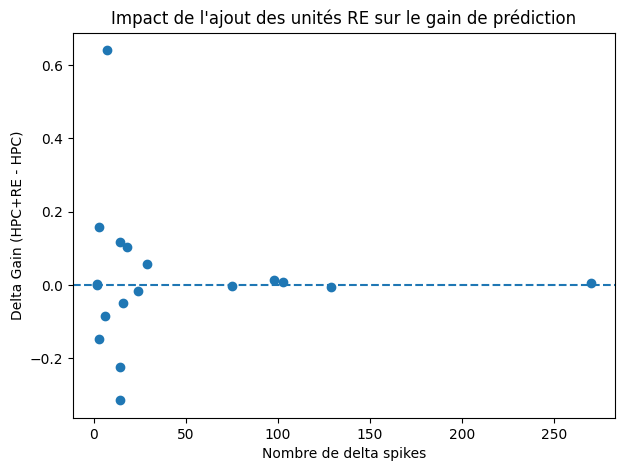

In [125]:
plt.figure(figsize=(7,5))

plt.scatter(comparison["n_delta_spikes"], comparison["delta_gain"])

plt.axhline(0, linestyle="--")

plt.xlabel("Nombre de delta spikes")
plt.ylabel("Delta Gain (HPC+RE - HPC)")
plt.title("Impact de l'ajout des unités RE sur le gain de prédiction")

plt.show()

In [126]:
results_re = {}
rows_re = []

for neuron_id in range (Y_mpfc.shape[1]):
    unit_id = mpfc_units_ids[neuron_id]
    y = Y_mpfc[:, neuron_id]

    print(
        f"Neurone {neuron_id+1}/{Y_mpfc.shape[1]} :"
        f" {unit_id} - {int(y.sum())} delta spikes")

    try:
        result = compute_pred_gain(X_re, y, n_shuffles=1000, random_state=42)
        results_re[unit_id] = result

        rows_re.append({
            "neuron_id" : unit_id,
            "n_delta_spikes" : int(y.sum()),
            "n_folds" : result["n_folds"],
            "e": result["e"],
            "e_shuffled": result["e_shuffled"],
            "gain": result["gain"],
            "n_not_converged": result["n_not_converged"]
        })

        print(f"  Gain : {result['gain']:.4f}")

    except Exception as error:
        print(f"Erreur pour le neurone {unit_id}: {error}")

        rows_re.append({
            "neuron_id" : unit_id,
            "n_delta_spikes" : int(y.sum()),
            "n_folds" : np.nan,
            "e": np.nan,
            "e_shuffled": np.nan,
            "gain": np.nan,
            "n_not_converged": np.nan
        })

df_results_re = pd.DataFrame(rows_re)

print(df_results_re[["neuron_id", "n_delta_spikes", "gain", "n_not_converged"]])

Neurone 1/18 : (10, np.int64(2)) - 6 delta spikes


/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/families/links.py:203: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10

  Gain : 0.7782
Neurone 2/18 : (10, np.int64(5)) - 24 delta spikes
  Gain : 1.1343
Neurone 3/18 : (10, np.int64(24)) - 129 delta spikes
  Gain : 0.9957
Neurone 4/18 : (10, np.int64(25)) - 29 delta spikes
  Gain : 1.0058
Neurone 5/18 : (11, np.int64(2)) - 270 delta spikes
  Gain : 1.0083
Neurone 6/18 : (11, np.int64(11)) - 16 delta spikes
  Gain : 1.0000
Neurone 7/18 : (11, np.int64(29)) - 2 delta spikes


/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return 

  Gain : 1.0000
Neurone 8/18 : (11, np.int64(33)) - 75 delta spikes
  Gain : 1.0018
Neurone 9/18 : (11, np.int64(37)) - 14 delta spikes
  Gain : 0.9968
Neurone 10/18 : (11, np.int64(40)) - 3 delta spikes


...

  Gain : nan
Neurone 13/18 : (12, np.int64(8)) - 14 delta spikes
  Gain : 0.9763
Neurone 14/18 : (12, np.int64(26)) - 3 delta spikes


/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return 

  Gain : 0.9814
Neurone 15/18 : (12, np.int64(33)) - 2 delta spikes


/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return 

  Gain : 1.0133
Neurone 16/18 : (12, np.int64(37)) - 98 delta spikes
  Gain : 1.0061
Neurone 17/18 : (12, np.int64(38)) - 103 delta spikes
  Gain : 1.0068
Neurone 18/18 : (12, np.int64(39)) - 14 delta spikes
  Gain : 0.9261
   neuron_id  n_delta_spikes      gain  n_not_converged
0    (10, 2)               6  0.778196                0
1    (10, 5)              24  1.134301                0
2   (10, 24)             129  0.995679                0
3   (10, 25)              29  1.005812                0
4    (11, 2)             270  1.008297                0
5   (11, 11)              16  1.000000                0
6   (11, 29)               2  1.000000                0
7   (11, 33)              75  1.001823                0
8   (11, 37)              14  0.996804                0
9   (11, 40)               3  0.984250                0
10  (11, 43)              18  1.187661                0
11  (11, 44)               7       NaN                0
12   (12, 8)              14  0.976256          

In [127]:
comparison_all = df_results_hpc[["neuron_id", "n_delta_spikes", "gain"]].copy()

comparison_all = comparison.rename(columns={"gain": "gain_hpc"})

comparison_all["gain_re"] = df_results_re["gain"].values

comparison_all["gain_hpc_re"] = df_results_hpc_re["gain"].values

comparison_all["delta_gain"] = comparison_all["gain_hpc_re"] - comparison_all["gain_hpc"]

print(comparison_all.to_string(index=False))

neuron_id  n_delta_spikes  gain_hpc  gain_hpc_re  delta_gain  gain_re
  (10, 2)               6  1.000000     0.914011   -0.085989 0.778196
  (10, 5)              24  1.015301     1.000000   -0.015301 1.134301
 (10, 24)             129  0.999442     0.993946   -0.005496 0.995679
 (10, 25)              29  1.000000     1.057332    0.057332 1.005812
  (11, 2)             270  1.012976     1.019691    0.006715 1.008297
 (11, 11)              16  1.048578     1.000000   -0.048578 1.000000
 (11, 29)               2  1.000000     1.001212    0.001212 1.000000
 (11, 33)              75  1.045164     1.041481   -0.003683 1.001823
 (11, 37)              14  0.960004     0.736056   -0.223948 0.996804
 (11, 40)               3  0.833783     0.991146    0.157363 0.984250
 (11, 43)              18  0.999579     1.102710    0.103131 1.187661
 (11, 44)               7  0.364096     1.005095    0.640999      NaN
  (12, 8)              14  0.993625     0.679052   -0.314573 0.976256
 (12, 26)           

In [128]:
def build_matrix_window(units, delta_peaks, start, end):
    
    unit_ids = list(units.keys())

    X = np.zeros(
        (len(delta_peaks), len(unit_ids)),
        dtype=int
    )

    for j, unit_id in enumerate(unit_ids):

        spikes = np.asarray(units[unit_id])

        left = np.searchsorted(
            spikes,
            delta_peaks + start,
            side="left"
        )

        right = np.searchsorted(
            spikes,
            delta_peaks + end,
            side="left"
        )

        X[:, j] = right - left

    return X, unit_ids

re_windows = [
    (-0.500, -0.300),
    (-0.400, -0.200),
    (-0.300, -0.100),
    (-0.200,  0.000),
    (-0.100,  0.100),
    ( 0.000,  0.200)
]

In [129]:
re_matrices = {}

for start, end in re_windows:

    X_re_window, re_ids_window = build_matrix_window(
        re_units,
        delta_peaks,
        start,
        end
    )

    keep = X_re_window.sum(axis=0) > 0

    X_re_window = X_re_window[:, keep]

    re_ids_window = [
        unit_id
        for unit_id, k in zip(re_ids_window, keep)
        if k
    ]

    key = (start, end)

    re_matrices[key] = {
        "X": X_re_window,
        "unit_ids": re_ids_window
    }

    print(
        f"Fenêtre {start*1000:.0f} à {end*1000:.0f} ms : "
        f"{X_re_window.shape[1]} unités RE"
    )

Fenêtre -500 à -300 ms : 69 unités RE
Fenêtre -400 à -200 ms : 69 unités RE
Fenêtre -300 à -100 ms : 69 unités RE
Fenêtre -200 à 0 ms : 69 unités RE
Fenêtre -100 à 100 ms : 69 unités RE
Fenêtre 0 à 200 ms : 69 unités RE


In [130]:
j = mpfc_units_ids.index((11, 2))

y = Y_mpfc[:, j]

folds_test = make_folds(
    y,
    random_state=42
)

print("Nombre de delta spikes :", y.sum())
print("Nombre de folds :", len(folds_test))

X_test_re = re_matrices[(-0.200, 0.000)]["X"]

print("Dimensions RE :", X_test_re.shape)

Nombre de delta spikes : 270
Nombre de folds : 270
Dimensions RE : (3338, 69)


In [131]:
result_test_re = compute_pred_gain(
    X_test_re,
    y,
    n_shuffles=1000,
    random_state=42,
    folds=folds_test
)

print("Gain RE :", result_test_re["gain"])
print("e :", result_test_re["e"])
print("e_shuffled :", result_test_re["e_shuffled"])
print("Folds non convergés :", result_test_re["n_not_converged"])

Gain RE : 1.0079602010293556
e : 0.07576740936273207
e_shuffled : 0.0763705331727329
Folds non convergés : 0


In [132]:
delay_results = []

for start, end in re_windows:

    X_re_window = re_matrices[(start, end)]["X"]

    print(
        f"\nFenêtre RE : {start*1000:.0f} à {end*1000:.0f} ms"
    )

    for neuron_id in range(Y_mpfc.shape[1]):

        unit_id = mpfc_units_ids[neuron_id]
        y = Y_mpfc[:, neuron_id]

        try:

            result = compute_pred_gain(
                X_re_window,
                y,
                n_shuffles=1000,
                random_state=42
            )

            delay_results.append({
                "neuron_id": unit_id,
                "n_delta_spikes": int(y.sum()),
                "window_start_ms": int(start * 1000),
                "window_end_ms": int(end * 1000),
                "gain_re": result["gain"],
                "n_not_converged": result["n_not_converged"]
            })

        except Exception as error:

            delay_results.append({
                "neuron_id": unit_id,
                "n_delta_spikes": int(y.sum()),
                "window_start_ms": int(start * 1000),
                "window_end_ms": int(end * 1000),
                "gain_re": np.nan,
                "n_not_converged": np.nan
            })


Fenêtre RE : -500 à -300 ms


/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/families/links.py:203: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10


Fenêtre RE : -400 à -200 ms


/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return 


Fenêtre RE : -300 à -100 ms


...

/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return 


Fenêtre RE : -100 à 100 ms


/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return 


Fenêtre RE : 0 à 200 ms


/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return 

In [133]:
df_re_delays = pd.DataFrame(delay_results)

summary_re_delays = (
    df_re_delays
    .groupby(
        ["window_start_ms", "window_end_ms"]
    )["gain_re"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

summary_re_delays

,window_start_ms,window_end_ms,mean,median,count
0,-500,-300,0.989673,1.001166,18
1,-400,-200,1.034216,1.000000,18
2,-300,-100,0.972843,1.000000,18
3,-200,0,1.000200,1.000000,17
4,-100,100,0.990462,1.000000,18
5,0,200,0.996607,1.000000,17


In [134]:
hpc_re_delay_results = []

for neuron_id in range(Y_mpfc.shape[1]):

    unit_id = mpfc_units_ids[neuron_id]
    y = Y_mpfc[:, neuron_id]

    # mêmes folds pour toutes les comparaisons de ce neurone
    folds_neuron = make_folds(
        y,
        random_state=42
    )

    print(
        f"\nNeurone {unit_id} "
        f"({int(y.sum())} delta spikes)"
    )

    for start, end in re_windows:

        X_re_window = re_matrices[(start, end)]["X"]

        # HPC fixe + RE à ce délai
        X_hpc_re_window = np.column_stack(
            (X_hpc, X_re_window)
        )

        print(
            f"  HPC + RE {start*1000:.0f} à {end*1000:.0f} ms"
        )

        try:

            result = compute_pred_gain(
                X_hpc_re_window,
                y,
                n_shuffles=1000,
                random_state=42,
                folds=folds_neuron
            )

            hpc_re_delay_results.append({
                "neuron_id": unit_id,
                "n_delta_spikes": int(y.sum()),
                "window_start_ms": int(start * 1000),
                "window_end_ms": int(end * 1000),
                "gain_hpc_re": result["gain"],
                "e": result["e"],
                "e_shuffled": result["e_shuffled"],
                "n_not_converged": result["n_not_converged"]
            })

        except Exception as error:

            print("    ERREUR :", error)

            hpc_re_delay_results.append({
                "neuron_id": unit_id,
                "n_delta_spikes": int(y.sum()),
                "window_start_ms": int(start * 1000),
                "window_end_ms": int(end * 1000),
                "gain_hpc_re": np.nan,
                "e": np.nan,
                "e_shuffled": np.nan,
                "n_not_converged": np.nan
            })


Neurone (10, np.int64(2)) (6 delta spikes)
  HPC + RE -500 à -300 ms


/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return 

  HPC + RE -400 à -200 ms


/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return 

  HPC + RE -300 à -100 ms


...

/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return 

  HPC + RE -100 à 100 ms


/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return 

  HPC + RE 0 à 200 ms


/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return 

In [135]:
df_hpc_re_delays = pd.DataFrame(
    hpc_re_delay_results
)

df_hpc_re_delays.head()

,neuron_id,n_delta_spikes,window_start_ms,window_end_ms,gain_hpc_re,e,e_shuffled,n_not_converged
0,"(10, 2)",6,-500,-300,1.000000,1.766978e-31,1.766978e-31,0
1,"(10, 2)",6,-400,-200,1.016338,1.109162e-30,1.127283e-30,0
2,"(10, 2)",6,-300,-100,1.000000,1.029972e-33,1.029972e-33,0
3,"(10, 2)",6,-200,0,0.884485,3.653549e-33,3.231511e-33,0
4,"(10, 2)",6,-100,100,0.990214,2.290356e-32,2.267943e-32,0


In [136]:
print(df_results_hpc.columns)

Index(['neuron_id', 'n_delta_spikes', 'n_folds', 'e', 'e_shuffled', 'gain',
       'n_not_converged'],
      dtype='object')


In [137]:
comparison_delays = df_hpc_re_delays.merge(
    df_results_hpc[
        ["neuron_id", "gain"]
    ],
    on="neuron_id",
    how="left"
)

comparison_delays = comparison_delays.rename(
    columns={"gain": "gain_hpc"}
)

comparison_delays["delta_gain"] = (
    comparison_delays["gain_hpc_re"]
    - comparison_delays["gain_hpc"]
)

In [138]:
summary_hpc_re_delays = (
    comparison_delays
    .groupby(
        ["window_start_ms", "window_end_ms"]
    )["delta_gain"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

summary_hpc_re_delays

,window_start_ms,window_end_ms,mean,median,count
0,-500,-300,-0.022753,0.006199,18
1,-400,-200,0.016073,0.010979,18
2,-300,-100,0.059812,0.000000,18
3,-200,0,0.018691,0.005060,18
4,-100,100,0.073919,0.001678,18
5,0,200,0.066068,0.009201,18


In [139]:
pivot_delta = comparison_delays.pivot(
    index=["neuron_id", "n_delta_spikes"],
    columns="window_start_ms",
    values="delta_gain"
)

pivot_delta.columns = [
    f"{int(x)} ms"
    for x in pivot_delta.columns
]

pivot_delta

,,-500 ms,-400 ms,-300 ms,-200 ms,-100 ms,0 ms
neuron_id,n_delta_spikes,,,,,,
"(10, 2)",6,0.000000,0.016338,0.000000,-0.115515,-0.009786,0.000000
"(10, 5)",24,-0.698044,-0.125182,-0.015301,-0.015301,-0.015301,-0.045073
"(10, 24)",129,0.009868,0.012756,-0.002172,-0.005906,0.003356,0.003668
"(10, 25)",29,-0.035013,-0.037736,-0.035816,0.046377,-0.021226,-0.020618
"(11, 2)",270,0.016771,0.019350,0.016636,0.006461,0.010509,0.014657
"(11, 11)",16,-0.096441,0.012972,0.003062,-0.048578,0.803700,0.673873
"(11, 29)",2,0.002530,0.000000,0.000000,0.005737,0.000000,0.000000
"(11, 33)",75,-0.023901,-0.008708,-0.019148,-0.006259,-0.003310,0.036527
"(11, 37)",14,0.039996,0.039996,0.122866,-0.317457,-0.304459,0.077659


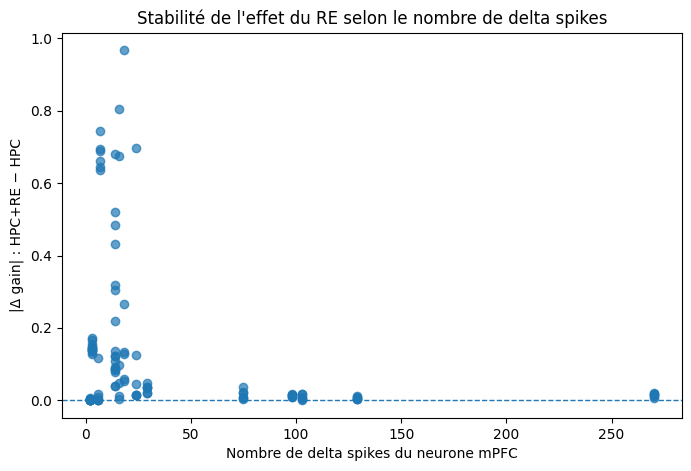

In [140]:
comparison_delays["abs_delta_gain"] = (
    comparison_delays["delta_gain"].abs()
)

plt.figure(figsize=(8, 5))

plt.scatter(
    comparison_delays["n_delta_spikes"],
    comparison_delays["abs_delta_gain"],
    alpha=0.7
)

plt.xlabel("Nombre de delta spikes du neurone mPFC")
plt.ylabel("|Δ gain| : HPC+RE − HPC")
plt.title("Stabilité de l'effet du RE selon le nombre de delta spikes")

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.show()

In [141]:
rho, p = spearmanr(
    comparison_delays["n_delta_spikes"],
    comparison_delays["abs_delta_gain"]
)

print("rho =", rho)
print("p =", p)

rho = -0.15266110042648884
p = 0.11472647126892718


In [142]:
stability_by_neuron = (
    comparison_delays
    .groupby(["neuron_id", "n_delta_spikes"])
    ["abs_delta_gain"]
    .mean()
    .reset_index()
)

rho_neuron, p_neuron = spearmanr(
    stability_by_neuron["n_delta_spikes"],
    stability_by_neuron["abs_delta_gain"]
)

print("rho par neurone =", rho_neuron)
print("p par neurone =", p_neuron)

rho par neurone = -0.16252666367868826
p par neurone = 0.5193514322268609


In [143]:
wilcoxon_results = []

for start, end in re_windows:

    temp = comparison_delays[
        (comparison_delays["window_start_ms"] == int(start * 1000)) &
        (comparison_delays["window_end_ms"] == int(end * 1000))
    ].dropna(
        subset=["gain_hpc", "gain_hpc_re"]
    )

    stat, p = wilcoxon(
        temp["gain_hpc_re"],
        temp["gain_hpc"]
    )

    wilcoxon_results.append({
        "window_start_ms": int(start * 1000),
        "window_end_ms": int(end * 1000),
        "n_neurons": len(temp),
        "median_delta_gain": temp["delta_gain"].median(),
        "p_value": p
    })

df_wilcoxon = pd.DataFrame(wilcoxon_results)

df_wilcoxon

,window_start_ms,window_end_ms,n_neurons,median_delta_gain,p_value
0,-500,-300,18,0.006199,0.876722
1,-400,-200,18,0.010979,0.351979
2,-300,-100,18,0.000000,0.820280
3,-200,0,18,0.005060,0.932281
4,-100,100,18,0.001678,0.437967
5,0,200,18,0.009201,0.147660


In [144]:
print(deltawaves.keys())

for key in deltawaves.keys():
    x = np.asarray(deltawaves[key])
    print(
        key,
        "shape =", x.shape,
        "dtype =", x.dtype
    )

dict_keys(['timestamps', 'peaks', 'peakNormedPower', 'detectorName', 'troughValue', 'badIntervals'])
timestamps shape = (3338, 2) dtype = float64
peaks shape = (3338,) dtype = float64
peakNormedPower shape = (3338,) dtype = float64
detectorName shape = () dtype = <U61
troughValue shape = (3338,) dtype = float64
badIntervals shape = (0,) dtype = uint8


In [145]:
print(deltawaves["detectorName"])

channel 159 (+1), CleanLFP, FindDeltaWaves, peak-trough > 3.7


In [146]:
# Fenêtre : -500 à +500 ms
window = 0.500

# Bins de 10 ms
bin_size = 0.010

bins = np.arange(
    -window,
    window + bin_size,
    bin_size
)

all_relative_spikes = []

for unit_id, spikes in mpfc_units.items():

    spikes = np.asarray(spikes)

    for delta in delta_peaks:

        left = np.searchsorted(
            spikes,
            delta - window,
            side="left"
        )

        right = np.searchsorted(
            spikes,
            delta + window,
            side="right"
        )

        relative_spikes = spikes[left:right] - delta

        all_relative_spikes.extend(relative_spikes)

all_relative_spikes = np.asarray(all_relative_spikes)

print("Nombre total de spikes autour des delta waves :",
      len(all_relative_spikes))

Nombre total de spikes autour des delta waves : 148802


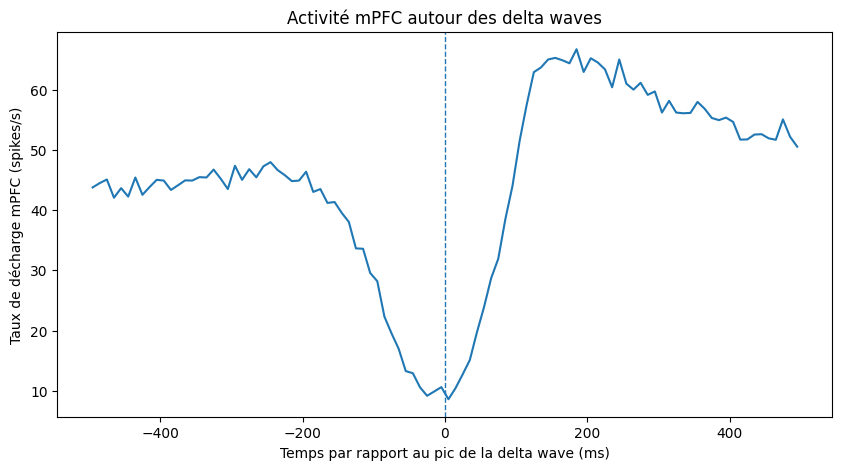

In [147]:
counts, edges = np.histogram(
    all_relative_spikes,
    bins=bins
)

# Nombre moyen de spikes par delta wave et par seconde
rate = counts / (len(delta_peaks) * bin_size)

centers = (edges[:-1] + edges[1:]) / 2

plt.figure(figsize=(10, 5))

plt.plot(
    centers * 1000,
    rate
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Temps par rapport au pic de la delta wave (ms)")
plt.ylabel("Taux de décharge mPFC (spikes/s)")
plt.title("Activité mPFC autour des delta waves")

plt.show()

In [148]:
j = mpfc_units_ids.index((11, 2))

y = Y_mpfc[:, j]

print("Nombre total de delta waves :", len(y))
print("Nombre de delta spikes :", y.sum())
print("Nombre de non-delta spikes :", len(y) - y.sum())
print("Valeurs uniques dans y :", np.unique(y, return_counts=True))

Nombre total de delta waves : 3338
Nombre de delta spikes : 270
Nombre de non-delta spikes : 3068
Valeurs uniques dans y : (array([0, 1]), array([3068,  270]))


In [149]:
folds = make_folds(y, random_state=42)

print("Nombre de folds :", len(folds))

# Vérification de quelques folds
for i in range(5):
    train_idx, test_idx = folds[i]

    print(
        f"Fold {i+1} :",
        "test =", len(test_idx),
        "| positifs test =", y[test_idx].sum(),
        "| négatifs test =", len(test_idx) - y[test_idx].sum(),
        "| positifs train =", y[train_idx].sum()
    )

# Vérifie que chaque événement est testé exactement une fois
all_test_idx = np.concatenate(
    [test_idx for _, test_idx in folds]
)

print("\nÉvénements testés :", len(all_test_idx))
print("Événements uniques testés :", len(np.unique(all_test_idx)))

Nombre de folds : 270
Fold 1 : test = 13 | positifs test = 1 | négatifs test = 12 | positifs train = 269
Fold 2 : test = 13 | positifs test = 1 | négatifs test = 12 | positifs train = 269
Fold 3 : test = 13 | positifs test = 1 | négatifs test = 12 | positifs train = 269
Fold 4 : test = 13 | positifs test = 1 | négatifs test = 12 | positifs train = 269
Fold 5 : test = 13 | positifs test = 1 | négatifs test = 12 | positifs train = 269

Événements testés : 3338
Événements uniques testés : 3338


In [150]:
predictions = np.full(len(y), np.nan)

for train_idx, test_idx in folds:

    X_train = X_hpc[train_idx]
    X_test = X_hpc[test_idx]

    y_train = y[train_idx]

    X_train_glm = sm.add_constant(
        X_train,
        has_constant="add"
    )

    X_test_glm = sm.add_constant(
        X_test,
        has_constant="add"
    )

    model = sm.GLM(
        y_train,
        X_train_glm,
        family=sm.families.Binomial()
    )

    results = model.fit()

    predictions[test_idx] = results.predict(
        X_test_glm
    )

print("NaN :", np.isnan(predictions).sum())

print("\nPrédictions pour y = 1")
print("moyenne :", predictions[y == 1].mean())
print("médiane :", np.median(predictions[y == 1]))

print("\nPrédictions pour y = 0")
print("moyenne :", predictions[y == 0].mean())
print("médiane :", np.median(predictions[y == 0]))

print("\nMin :", predictions.min())
print("Max :", predictions.max())

NaN : 0

Prédictions pour y = 1
moyenne : 0.10843143392702811
médiane : 0.08840082236526248

Prédictions pour y = 0
moyenne : 0.07878738184828117
médiane : 0.06847045345778868

Min : 0.00015460682586303568
Max : 0.5794746873796265


In [151]:
errors = np.abs(predictions - y)

errors_pos = errors[y == 1]
errors_neg = errors[y == 0]

print("ERREUR GLOBALE")
print("moyenne :", np.mean(errors))
print("médiane :", np.median(errors))

print("\nERREUR POUR y = 1")
print("moyenne :", np.mean(errors_pos))
print("médiane :", np.median(errors_pos))

print("\nERREUR POUR y = 0")
print("moyenne :", np.mean(errors_neg))
print("médiane :", np.median(errors_neg))

print("\nNombre y=1 :", len(errors_pos))
print("Nombre y=0 :", len(errors_neg))

ERREUR GLOBALE
moyenne : 0.1445306172409314
médiane : 0.0726551319778615

ERREUR POUR y = 1
moyenne : 0.8915685660729717
médiane : 0.9115991776347375

ERREUR POUR y = 0
moyenne : 0.07878738184828117
médiane : 0.06847045345778868

Nombre y=1 : 270
Nombre y=0 : 3068


In [152]:
unit_id = (11, 2)
spikes = np.asarray(mpfc_units[unit_id])

relative_spikes = []

for delta in delta_peaks:
    left = np.searchsorted(
        spikes,
        delta - 0.050,
        side="left"
    )
    right = np.searchsorted(
        spikes,
        delta + 0.050,
        side="right"
    )

    relative_spikes.extend(
        spikes[left:right] - delta
    )

relative_spikes = np.asarray(relative_spikes)

print("Nombre de spikes entre -50 et +50 ms :", len(relative_spikes))
print("Nombre dans ±15 ms :", np.sum(np.abs(relative_spikes) <= 0.015))

Nombre de spikes entre -50 et +50 ms : 1035
Nombre dans ±15 ms : 290


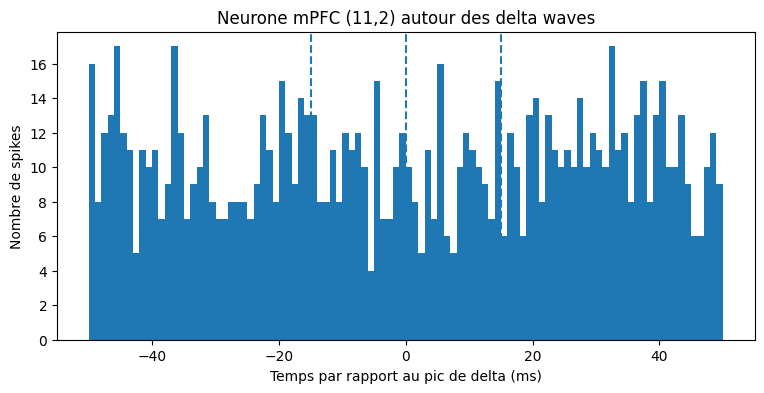

In [153]:
plt.figure(figsize=(9, 4))

plt.hist(
    relative_spikes * 1000,
    bins=np.arange(-50, 51, 1)
)

plt.axvline(-15, linestyle="--")
plt.axvline(0, linestyle="--")
plt.axvline(15, linestyle="--")

plt.xlabel("Temps par rapport au pic de delta (ms)")
plt.ylabel("Nombre de spikes")
plt.title("Neurone mPFC (11,2) autour des delta waves")

plt.show()

In [154]:
predictions_l2 = np.full(len(y), np.nan)

for train_idx, test_idx in folds:

    X_train = X_hpc[train_idx]
    X_test = X_hpc[test_idx]

    y_train = y[train_idx]

    # Normalisation apprise UNIQUEMENT sur le train
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Régression logistique avec régularisation L2
    model_l2 = LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="lbfgs",
        max_iter=2000
    )

    model_l2.fit(
        X_train_scaled,
        y_train
    )

    predictions_l2[test_idx] = model_l2.predict_proba(
        X_test_scaled
    )[:, 1]

print("NaN :", np.isnan(predictions_l2).sum())

print("\nPrédictions L2 pour y = 1")
print("moyenne :", predictions_l2[y == 1].mean())
print("médiane :", np.median(predictions_l2[y == 1]))

print("\nPrédictions L2 pour y = 0")
print("moyenne :", predictions_l2[y == 0].mean())
print("médiane :", np.median(predictions_l2[y == 0]))

print("\nMin :", predictions_l2.min())
print("Max :", predictions_l2.max())

NaN : 0

Prédictions L2 pour y = 1
moyenne : 0.10830510821910921
médiane : 0.0883832012745511

Prédictions L2 pour y = 0
moyenne : 0.07879025764670967
médiane : 0.06862027806633848

Min : 0.00019048551985340487
Max : 0.5778806096043424


In [155]:
errors_l2 = np.abs(
    predictions_l2 - y
)

e_l2 = np.median(errors_l2)

rng = np.random.default_rng(42)

shuffled_errors_l2 = []

for i in range(1000):

    shuffled_predictions = rng.permutation(
        predictions_l2
    )

    shuffled_error = np.median(
        np.abs(shuffled_predictions - y)
    )

    shuffled_errors_l2.append(
        shuffled_error
    )

e_shuffled_l2 = np.median(
    shuffled_errors_l2
)

g_l2 = e_shuffled_l2 / e_l2

print("e L2 =", e_l2)
print("e shuffled L2 =", e_shuffled_l2)
print("gain L2 =", g_l2)

print("\nRappel GLM Todorova :")
print("gain GLM ≈ 1.01298")

e L2 = 0.07284089328854929
e shuffled L2 = 0.0736374005761536
gain L2 = 1.010934891812063

Rappel GLM Todorova :
gain GLM ≈ 1.01298


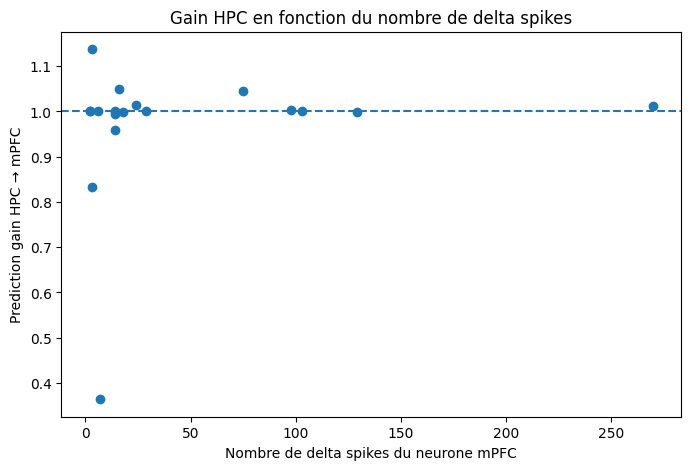

In [156]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_results_hpc["n_delta_spikes"],
    df_results_hpc["gain"]
)

plt.axhline(
    1,
    linestyle="--"
)

plt.xlabel("Nombre de delta spikes du neurone mPFC")
plt.ylabel("Prediction gain HPC → mPFC")
plt.title("Gain HPC en fonction du nombre de delta spikes")

plt.show()

In [157]:
rho, p = spearmanr(
    df_results_hpc["n_delta_spikes"],
    df_results_hpc["gain"]
)

print("Spearman rho =", rho)
print("p =", p)

Spearman rho = 0.2772040838648302
p = 0.2654303051766455


In [158]:
def build_hpc_sequence_exact(hpc_units, delta_peaks):

    unit_ids = list(hpc_units.keys())

    bin_edges = np.linspace(-0.200, 0.0, 21)

    bin_edges[0] = -0.200
    bin_edges[-1] = 0.0

    X_seq = np.zeros(
        (len(delta_peaks), len(unit_ids), 20),
        dtype=np.float32
    )

    for neuron_idx, unit_id in enumerate(unit_ids):

        spikes = np.asarray(hpc_units[unit_id])

        for bin_idx in range(20):

            # Pour chaque bin, m�mes r�gles :
            # [borne gauche, borne droite[
            left = np.searchsorted(
                spikes,
                delta_peaks + bin_edges[bin_idx],
                side="left"
            )

            right = np.searchsorted(
                spikes,
                delta_peaks + bin_edges[bin_idx + 1],
                side="left"
            )

            X_seq[:, neuron_idx, bin_idx] = (
                right - left
            )

    return X_seq, unit_ids, bin_edges

In [159]:
X_seq, hpc_seq_unit_ids, seq_edges = build_hpc_sequence_exact(
    hpc_units,
    delta_peaks
)

X_seq_sum = X_seq.sum(axis=2)

print("Shape X_seq :", X_seq.shape)

print(
    "Nombre de différences :",
    np.sum(X_seq_sum != X_hpc)
)

print(
    "Différence maximale :",
    np.max(np.abs(X_seq_sum - X_hpc))
)

Shape X_seq : (3338, 61, 20)
Nombre de différences : 13
Différence maximale : 1.0


In [160]:
j = mpfc_units_ids.index((11, 2))
y_cnn = Y_mpfc[:, j].astype(np.float32)

print("X_seq :", X_seq.shape)
print("y_cnn :", y_cnn.shape)
print("Positifs :", int(y_cnn.sum()))
print("Négatifs :", len(y_cnn) - int(y_cnn.sum()))

X_seq : (3338, 61, 20)
y_cnn : (3338,)
Positifs : 270
Négatifs : 3068


In [162]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X_seq,
    y_cnn,
    test_size=0.20,
    stratify=y_cnn,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=0.25,
    stratify=y_dev,
    random_state=42
)

In [163]:
X_train_cnn = np.transpose(X_train, (0, 2, 1))
X_val_cnn = np.transpose(X_val, (0, 2, 1))
X_test_cnn = np.transpose(X_test, (0, 2, 1))

print("TRAIN :", X_train_cnn.shape)
print("VALIDATION :", X_val_cnn.shape)
print("TEST :", X_test_cnn.shape)

TRAIN : (2002, 20, 61)
VALIDATION : (668, 20, 61)
TEST : (668, 20, 61)


In [165]:
model_cnn = models.Sequential([
    layers.Input(shape=(20, 61)),

    layers.Conv1D(
        filters=16,
        kernel_size=3,
        activation="relu"
    ),

    layers.MaxPooling1D(pool_size=2),

    layers.Flatten(),

    layers.Dense(
        16,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])

model_cnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="auc_roc"),
        tf.keras.metrics.AUC(curve="PR", name="auc_pr")
    ]
)

model_cnn.summary()

E0000 00:00:1788882266.421256  235480 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 18, 16)         │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 9, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 144)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,281 (20.63 KB)

 Trainable params: 5,281 (20.63 KB)

 Non-trainable params: 0 (0.00 B)

In [166]:
early_stopping = EarlyStopping(
    monitor="val_auc_pr",
    mode="max",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [167]:
history = model_cnn.fit(
    X_train_cnn,
    y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - auc_pr: 0.0807 - auc_roc: 0.5077 - loss: 0.4012 - val_auc_pr: 0.0853 - val_auc_roc: 0.5166 - val_loss: 0.3067
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - auc_pr: 0.0846 - auc_roc: 0.5224 - loss: 0.3055 - val_auc_pr: 0.0862 - val_auc_roc: 0.5196 - val_loss: 0.2939
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - auc_pr: 0.1013 - auc_roc: 0.5938 - loss: 0.2855 - val_auc_pr: 0.0859 - val_auc_roc: 0.5233 - val_loss: 0.2889
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - auc_pr: 0.0969 - auc_roc: 0.5769 - loss: 0.2867 - val_auc_pr: 0.0854 - val_auc_roc: 0.5252 - val_loss: 0.2876
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - auc_pr: 0.1196 - auc_roc: 0.6590 - loss: 0.2700 - val_auc_pr: 0.0849 - val_auc_roc: 0.5280 - val_loss: 0.2844
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - auc_pr: 0.1486 - auc_roc: 0.6841 - loss: 0.2658 - val_auc_pr: 0.0858 - val_auc_roc: 0.5332 - val_loss: 0.2855
Epoch 7/100
63/6

In [168]:
X_dev_cnn = np.concatenate(
    [X_train_cnn, X_val_cnn],
    axis=0
)

y_dev_cnn = np.concatenate(
    [y_train, y_val],
    axis=0
)

print("X_dev_cnn :", X_dev_cnn.shape)
print("y_dev_cnn :", y_dev_cnn.shape)
print("positifs :", int(y_dev_cnn.sum()))
print("négatifs :", len(y_dev_cnn) - int(y_dev_cnn.sum()))

X_dev_cnn : (2670, 20, 61)
y_dev_cnn : (2670,)
positifs : 216
négatifs : 2454


In [169]:
def build_cnn(
    filters=16,
    kernel_size=3,
    dense_units=16,
    dropout=0.3,
    learning_rate=1e-3
):

    model = models.Sequential([
        layers.Input(shape=(20, 61)),

        layers.Conv1D(
            filters=filters,
            kernel_size=kernel_size,
            activation="relu"
        ),

        layers.MaxPooling1D(pool_size=2),

        layers.Flatten(),

        layers.Dense(
            dense_units,
            activation="relu"
        ),

        layers.Dropout(dropout),

        layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy"
    )

    return model

In [170]:
cnn_classifier = KerasClassifier(
    model=build_cnn,
    epochs=30,
    batch_size=32,
    verbose=0,
    random_state=42
)

In [171]:
def ap_scorer(estimator, X, y):
    proba = estimator.predict_proba(X)

    if proba.ndim == 2:
        proba = proba[:, 1]

    return average_precision_score(y, proba)

In [172]:
param_grid = {
    "model__filters": [8, 16, 32],
    "model__kernel_size": [2, 3, 5],
    "model__dense_units": [8, 16],
    "model__dropout": [0.2, 0.4],
    "model__learning_rate": [3e-4, 1e-3]
}

In [173]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [174]:
grid_search = GridSearchCV(
    estimator=cnn_classifier,
    param_grid=param_grid,
    scoring=ap_scorer,
    cv=cv,
    n_jobs=1,
    verbose=2
)

In [175]:
grid_search.fit(
    X_dev_cnn,
    y_dev_cnn
)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


E0000 00:00:1788882486.628182  235480 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  23.3s


E0000 00:00:1788882509.899738  235480 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  21.6s


...

[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  23.9s


E0000 00:00:1788890543.105434  235480 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  23.8s


E0000 00:00:1788890566.935443  235480 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


,estimator,KerasClassifi..._weight=None )
,param_grid,"{'model__dense_units': [8, 16], 'model__dropout': [0.2, 0.4], 'model__filters': [8, 16, ...], 'model__kernel_size': [2, 3, ...], ...}"
,scoring,<function ap_...x78d639baff40>
,n_jobs,1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,model,<function bui...x78d639d7bb50>


In [176]:
print("Meilleur score :", grid_search.best_score_)
print("Meilleurs paramètres :", grid_search.best_params_)

Meilleur score : 0.15054564682145816
Meilleurs paramètres : {'model__dense_units': 8, 'model__dropout': 0.2, 'model__filters': 32, 'model__kernel_size': 5, 'model__learning_rate': 0.0003}


In [177]:
def build_cnn2(
    filters=16,
    kernel_size=3,
    dense_units=16,
    dropout=0.3,
    learning_rate=0.0003,
    n_conv=1,
    n_dense=1
):

    model = models.Sequential()

    model.add(layers.Input(shape=(20, 61)))

    # Couches Conv1D
    for _ in range(n_conv):
        model.add(
            layers.Conv1D(
                filters=filters,
                kernel_size=kernel_size,
                activation="relu"
            )
        )

    model.add(layers.MaxPooling1D(pool_size=2))
    model.add(layers.Flatten())

    # Couches Dense
    for _ in range(n_dense):
        model.add(
            layers.Dense(
                dense_units,
                activation="relu"
            )
        )

    model.add(layers.Dropout(dropout))

    model.add(
        layers.Dense(
            1,
            activation="sigmoid"
        )
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy"
    )

    return model

In [179]:
cnn_classifier = KerasClassifier(
    model=build_cnn2,
    epochs=30,
    batch_size=32,
    verbose=0,
    random_state=42
)

grid_layers = GridSearchCV(
    cnn_classifier,
    {
        "model__n_conv": [1, 2, 3, 4, 5],
        "model__n_dense": [0, 1, 2, 3, 4]
    },
    scoring=ap_scorer,
    cv=cv,
    n_jobs=1
)

grid_layers.fit(X_dev_cnn, y_dev_cnn)

print(grid_layers.best_score_)
print(grid_layers.best_params_)

E0000 00:00:1788943468.486286  235480 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1788943488.794446  235480 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),

0.138147662213161
{'model__n_conv': 3, 'model__n_dense': 0}


In [186]:
X_cnn = np.transpose(X_seq, (0, 2, 1))


def build_best_cnn():

    model = models.Sequential([
        layers.Input(shape=(20, 61)),

        layers.Conv1D(
            filters=32,
            kernel_size=5,
            activation="relu"
        ),

        layers.MaxPooling1D(pool_size=2),

        layers.Flatten(),

        layers.Dense(
            8,
            activation="relu"
        ),

        layers.Dropout(0.2),

        layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.0003
        ),
        loss="binary_crossentropy"
    )

    return model


results = []


for j, unit_id in enumerate(mpfc_units_ids):

    y = Y_mpfc[:, j]

    n_positive = int(y.sum())

    # Maximum 5 folds
    n_folds = min(5, n_positive)

    scores = []

    print(f"\n{unit_id} - {n_positive} delta-spikes")


    cv_neuron = StratifiedKFold(
        n_splits=n_folds,
        shuffle=True,
        random_state=42
    )


    for train_idx, val_idx in cv_neuron.split(X_cnn, y):

        tf.keras.backend.clear_session()

        model = build_best_cnn()

        model.fit(
            X_cnn[train_idx],
            y[train_idx],
            epochs=30,
            batch_size=32,
            verbose=0
        )

        pred = model.predict(
            X_cnn[val_idx],
            verbose=0
        ).ravel()

        score = average_precision_score(
            y[val_idx],
            pred
        )

        scores.append(score)


    results.append({
        "unit_id": unit_id,
        "n_delta_spikes": n_positive,
        "baseline_AP": n_positive / len(y),
        "mean_AP": np.mean(scores),
        "std_AP": np.std(scores)
    })

    print("AP moyenne :", round(np.mean(scores), 3))


df_cnn = pd.DataFrame(results)

df_cnn


(10, np.int64(2)) - 6 delta-spikes
AP moyenne : 0.004

(10, np.int64(5)) - 24 delta-spikes
AP moyenne : 0.016

(10, np.int64(24)) - 129 delta-spikes
AP moyenne : 0.052

(10, np.int64(25)) - 29 delta-spikes
AP moyenne : 0.015

(11, np.int64(2)) - 270 delta-spikes
AP moyenne : 0.114

(11, np.int64(11)) - 16 delta-spikes
AP moyenne : 0.015

(11, np.int64(29)) - 2 delta-spikes
AP moyenne : 0.002

(11, np.int64(33)) - 75 delta-spikes
AP moyenne : 0.054

(11, np.int64(37)) - 14 delta-spikes
AP moyenne : 0.006

(11, np.int64(40)) - 3 delta-spikes
AP moyenne : 0.003

(11, np.int64(43)) - 18 delta-spikes
AP moyenne : 0.039

(11, np.int64(44)) - 7 delta-spikes
AP moyenne : 0.008

(12, np.int64(8)) - 14 delta-spikes
AP moyenne : 0.011

(12, np.int64(26)) - 3 delta-spikes
AP moyenne : 0.01

(12, np.int64(33)) - 2 delta-spikes
AP moyenne : 0.003

(12, np.int64(37)) - 98 delta-spikes
AP moyenne : 0.042

(12, np.int64(38)) - 103 delta-spikes
AP moyenne : 0.043

(12, np.int64(39)) - 14 delta-spikes
A

,unit_id,n_delta_spikes,baseline_AP,mean_AP,std_AP
0,"(10, 2)",6,0.001797,0.003807,0.001831
1,"(10, 5)",24,0.007190,0.015977,0.005827
2,"(10, 24)",129,0.038646,0.051502,0.016559
3,"(10, 25)",29,0.008688,0.014607,0.010470
4,"(11, 2)",270,0.080887,0.113895,0.022531
5,"(11, 11)",16,0.004793,0.014811,0.009038
6,"(11, 29)",2,0.000599,0.001805,0.000646
7,"(11, 33)",75,0.022469,0.054202,0.022810
8,"(11, 37)",14,0.004194,0.005995,0.002592
9,"(11, 40)",3,0.000899,0.003115,0.002026


In [188]:
n_shuffles = 100

shuffle_results = []

for j, unit_id in enumerate(mpfc_units_ids):

    y = Y_mpfc[:, j].copy()
    real_ap = df_cnn.loc[j, "mean_AP"]

    shuffled_AP = []

    print(f"\n{unit_id}")

    for s in range(n_shuffles):

        # Mélange des labels
        rng = np.random.default_rng(s)
        y_shuffle = rng.permutation(y)

        # Un split stratifié
        train_idx, val_idx = next(
            StratifiedKFold(
                n_splits=5,
                shuffle=True,
                random_state=s
            ).split(X_cnn, y_shuffle)
        )

        tf.keras.backend.clear_session()

        model = build_best_cnn()

        model.fit(
            X_cnn[train_idx],
            y_shuffle[train_idx],
            epochs=30,
            batch_size=32,
            verbose=0
        )

        pred = model.predict(
            X_cnn[val_idx],
            verbose=0
        ).ravel()

        ap = average_precision_score(
            y_shuffle[val_idx],
            pred
        )

        shuffled_AP.append(ap)

    # p-value empirique
    p_value = (
        np.sum(np.array(shuffled_AP) >= real_ap) + 1
    ) / (n_shuffles + 1)

    shuffle_results.append({
        "unit_id": unit_id,
        "real_AP": real_ap,
        "shuffle_AP": np.mean(shuffled_AP),
        "shuffle_std": np.std(shuffled_AP),
        "p_value": p_value
    })

    print(
        "réel =", round(real_ap, 4),
        "| shuffle =", round(np.mean(shuffled_AP), 4),
        "| p =", round(p_value, 4)
    )


df_shuffle = pd.DataFrame(shuffle_results)

df_shuffle


(10, np.int64(2))
réel = 0.0038 | shuffle = 0.0065 | p = 0.3465

(10, np.int64(5))
réel = 0.016 | shuffle = 0.0138 | p = 0.2277

(10, np.int64(24))
réel = 0.0515 | shuffle = 0.0459 | p = 0.1881

(10, np.int64(25))
réel = 0.0146 | shuffle = 0.0196 | p = 0.4653

(11, np.int64(2))
réel = 0.1139 | shuffle = 0.0877 | p = 0.0396

(11, np.int64(11))
réel = 0.0148 | shuffle = 0.0105 | p = 0.1485

(11, np.int64(29))


/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: User

réel = 0.0018 | shuffle = 0.0 | p = 0.0099

(11, np.int64(33))
réel = 0.0542 | shuffle = 0.0318 | p = 0.0594

(11, np.int64(37))
réel = 0.006 | shuffle = 0.0134 | p = 0.5644

(11, np.int64(40))


/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/sklearn/model_selecti

réel = 0.0031 | shuffle = 0.0089 | p = 0.4455

(11, np.int64(43))
réel = 0.0392 | shuffle = 0.012 | p = 0.0099

(11, np.int64(44))
réel = 0.0078 | shuffle = 0.0097 | p = 0.1188

(12, np.int64(8))
réel = 0.0107 | shuffle = 0.0114 | p = 0.3069

(12, np.int64(26))


/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/sklearn/model_selecti

réel = 0.0101 | shuffle = 0.0067 | p = 0.1188

(12, np.int64(33))


/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/media/data-103/Laura/DESU/Projet_final/.venv/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: User

réel = 0.0034 | shuffle = 0.0 | p = 0.0099

(12, np.int64(37))
réel = 0.0416 | shuffle = 0.0392 | p = 0.2871

(12, np.int64(38))
réel = 0.0427 | shuffle = 0.0379 | p = 0.2673

(12, np.int64(39))
réel = 0.0068 | shuffle = 0.0102 | p = 0.495


,unit_id,real_AP,shuffle_AP,shuffle_std,p_value
0,"(10, 2)",0.003807,0.006450,0.014185,0.346535
1,"(10, 5)",0.015977,0.013802,0.008954,0.227723
2,"(10, 24)",0.051502,0.045937,0.011091,0.188119
3,"(10, 25)",0.014607,0.019626,0.024472,0.465347
4,"(11, 2)",0.113895,0.087671,0.012558,0.039604
5,"(11, 11)",0.014811,0.010511,0.010976,0.148515
6,"(11, 29)",0.001805,0.000000,0.000000,0.009901
7,"(11, 33)",0.054202,0.031776,0.022577,0.059406
8,"(11, 37)",0.005995,0.013363,0.033729,0.564356
9,"(11, 40)",0.003115,0.008882,0.021250,0.445545


In [189]:
bin_edges = np.linspace(-0.200, 0, 21)

re_unit_ids = list(re_units.keys())

X_seq_nr = np.zeros(
    (len(delta_peaks), len(re_unit_ids), 20),
    dtype=np.float32
)

for j, unit_id in enumerate(re_unit_ids):

    spikes = np.asarray(re_units[unit_id])

    for i, delta in enumerate(delta_peaks):

        counts, _ = np.histogram(
            spikes,
            bins=delta + bin_edges
        )

        X_seq_nr[i, j, :] = counts


print("HPC :", X_seq.shape)
print("NR  :", X_seq_nr.shape)

HPC : (3338, 61, 20)
NR  : (3338, 69, 20)


In [190]:
X_seq_hpc_nr = np.concatenate(
    [X_seq, X_seq_nr],
    axis=1
)

X_cnn_hpc_nr = np.transpose(
    X_seq_hpc_nr,
    (0, 2, 1)
)

print("HPC + NR :", X_cnn_hpc_nr.shape)

HPC + NR : (3338, 20, 130)


In [191]:
def build_cnn_hpc_nr():

    model = models.Sequential([
        layers.Input(shape=(20, X_cnn_hpc_nr.shape[2])),

        layers.Conv1D(
            filters=32,
            kernel_size=5,
            activation="relu"
        ),

        layers.MaxPooling1D(pool_size=2),

        layers.Flatten(),

        layers.Dense(8, activation="relu"),

        layers.Dropout(0.2),

        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.0003
        ),
        loss="binary_crossentropy"
    )

    return model